# **1. Time**

### LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import os
import IPython.display as ipd
import librosa
import soundfile as sf
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import models
from tensorflow.keras import layers
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import json
from datetime import datetime

### Data Paths

In [2]:
output_segmented_cats_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats"
output_segmented_dogs_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs"

## **1. Data Preprocessing**

In [3]:
def parse_dataset(dataset_paths):
    X = []
    y = []
    for index, dataset in enumerate(dataset_paths):
        print("[+] Parsing {} data...".format(dataset))
        for fname in os.listdir(dataset):
            wav, sr = librosa.load(os.path.join(dataset, fname), sr=None)
            X.append(wav)
            y.append(index)
    return (X, y)

dataset_paths = [output_segmented_cats_path, output_segmented_dogs_path]
X, y = parse_dataset(dataset_paths)

[+] Parsing C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats data...


c:\Users\Ale\Documents\Lab01\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[+] Parsing C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs data...


In [4]:
print("The length of the data set is: ", len(X))

The length of the data set is:  580


In [5]:
print(len(X[0]))

66150


#### We divide the dataset into training and testing.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [7]:
print("Length of training subset: ", len(X_train))
print("Lenght of testing subset: ", len(X_test))

Length of training subset:  493
Lenght of testing subset:  87


Text(0.5, 1.0, 'Distribution of classes in the training set')

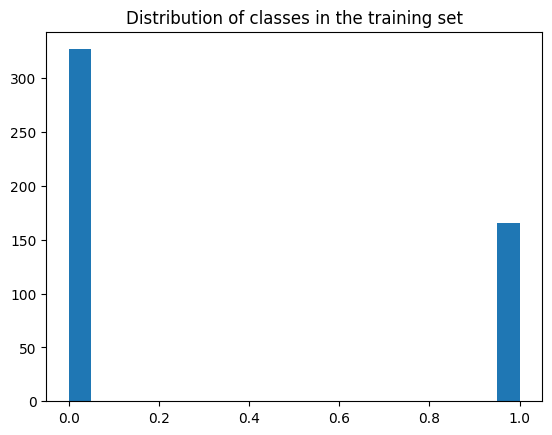

In [8]:
plt.hist(y_train, bins=20)
plt.title("Distribution of classes in the training set")

### **1. Model Construction**

In [9]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [19]:
network = models.Sequential()

network.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
network.add(layers.Dense(32, activation='relu'))
network.add(layers.Dense(1, activation='sigmoid'))

network.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy', 'Precision'])


history = network.fit(X_train, 
                      y_train,
                      batch_size=32,
                      epochs=15, 
                      validation_data=(X_test, y_test))

Epoch 1/15
16/16 [==============================] - 2s 36ms/step - loss: 0.7124 - accuracy: 0.6126 - precision: 0.3684 - val_loss: 0.7554 - val_accuracy: 0.6322 - val_precision: 0.4167
Epoch 2/15
16/16 [==============================] - 0s 30ms/step - loss: 0.3026 - accuracy: 0.9412 - precision: 1.0000 - val_loss: 0.8198 - val_accuracy: 0.5977 - val_precision: 0.3871
Epoch 3/15
16/16 [==============================] - 0s 21ms/step - loss: 0.1712 - accuracy: 0.9777 - precision: 1.0000 - val_loss: 0.8910 - val_accuracy: 0.6092 - val_precision: 0.4118
Epoch 4/15
16/16 [==============================] - 0s 20ms/step - loss: 0.1093 - accuracy: 0.9919 - precision: 1.0000 - val_loss: 0.9621 - val_accuracy: 0.6322 - val_precision: 0.4333
Epoch 5/15
16/16 [==============================] - 0s 20ms/step - loss: 0.0770 - accuracy: 0.9919 - precision: 1.0000 - val_loss: 1.0307 - val_accuracy: 0.6437 - val_precision: 0.4483
Epoch 6/15
16/16 [==============================] - 0s 19ms/step - loss: 0.

In [20]:
y_pred_probs = network.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

3/3 [==============================] - 0s 5ms/step


In [21]:
y_test = np.array(y_test).flatten()

### **RESULTS**

In [22]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6896551724137931
Precision: 0.52
Recall: 0.4642857142857143
F1 Score: 0.49056603773584906

Confusion Matrix:
[[47 12]
 [15 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        59
           1       0.52      0.46      0.49        28

    accuracy                           0.69        87
   macro avg       0.64      0.63      0.63        87
weighted avg       0.68      0.69      0.68        87



In [23]:
from IPython.display import display, HTML

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy()

display(HTML(f"""
<div style="
    background-color:#ffe6f2;
    padding:15px;
    border-radius:10px;
    font-family:Arial;
    width:400px">
    <h3 style="color:#d63384;"> Model Metrics </h3>
    <p><b>Accuracy:</b> {acc:.3f}</p>
    <p><b>Precision:</b> {prec:.3f}</p>
    <p><b>Recall:</b> {rec:.3f}</p>
    <p><b>F1 Score:</b> {f1:.3f}</p>
    <p><b>AUC:</b> {auc:.3f}</p>
    
</div>
"""))


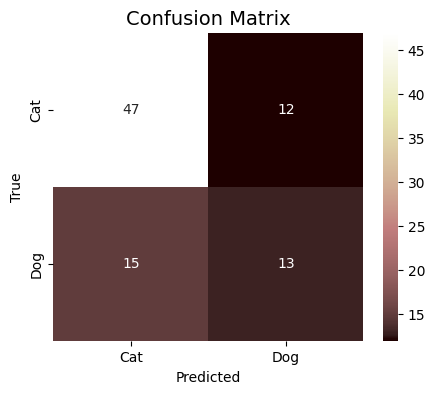

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="pink",
            xticklabels=["Cat", "Dog"],
            yticklabels=["Cat", "Dog"])

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [25]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.style.background_gradient(cmap="RdPu")


,precision,recall,f1-score,support
0,0.758065,0.796610,0.776860,59.000000
1,0.520000,0.464286,0.490566,28.000000
accuracy,0.689655,0.689655,0.689655,0.689655
macro avg,0.639032,0.630448,0.633713,87.000000
weighted avg,0.681446,0.689655,0.684719,87.000000


In [26]:
model_name = "1. MLP"
representation = "Time Domain"
save_dir_path = "model_metrics"

metrics_dict = {"model": model_name,
        "representation": representation,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "auc": float(auc),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

if not os.path.exists(save_dir_path):
    os.makedirs(save_dir_path, exist_ok=True)

file_path = os.path.join(save_dir_path, f"{model_name}_{representation}.json")

with open(file_path, "w") as f: json.dump(metrics_dict, f, indent=4)
print(f"Metrics saved to: {file_path}")

Metrics saved to: model_metrics\1. MLP_Time Domain.json


### **Conclussions**

Accuracy: 0.65
→ Only slightly better than random guessing (0.5).

Precision (Dogs): 0.46
→ Less than half of predicted dogs are correct.

Recall (Dogs): 0.42
→ It misses more than 50% of actual dogs.

F1: 0.44
→ Weak performance for class 1.